### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d
from scipy import integrate

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Input data:

In [5]:
mp = 41.9       #  (submerged pipe weight) [kg/m]
N = 12       # number of modelling nodes

In [6]:
qw = 1025 # Water density [kg/m3]
d0 = 0.2731 # Outer diameter of pipe, [m]
dI= (273.1-15.9*2)/1000 # Inner diameter of pipe, [m]

In [7]:
# Underwater current: 
dv1_curr = 0
dv2_curr = 0
dv3_curr = 0

In [8]:
Fx_0 = 449*1000
Fy_0 = 0.7*Fx_0
LTD = 387

In [9]:
E = 207e9
G = 79.3e9

In [10]:
# integration parameters
tspan = (0., 2)

### Main functions:

In [11]:
Ar=np.pi*(d0/2)**2

In [12]:
def Πe(φ,θ,ψ):
    return np.array([[np.cos(θ),0,np.cos(φ)*np.sin(θ)],
                  [0,1,-np.sin(φ)],
                  [-np.sin(θ),0,np.cos(φ)*np.cos(θ)]])

In [13]:
def Ret_e_t(φ,θ,ψ):
        Cφ=np.array([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.array([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.array([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return Cθ @ Cφ @ Cψ

In [14]:
diag_J_t_rho = 1e2*np.array([1, 1, 2]) # [m^4] 
J_t_rho = np.diag(diag_J_t_rho)

In [15]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [16]:
diag_CR = 1e11*np.array([1, 1, 1]) 
CR=np.diag(diag_CR)

In [17]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [18]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [19]:
def I_e_rho(φ,θ,ψ):
    return Ret_e_t(φ,θ,ψ) @ J_t_rho @ Ret_e_t(φ,θ,ψ).T

In [20]:
def phi(x,y,z): return np.array([x,y,z]) 
def theta(φ,θ,ψ): return np.array([φ,θ,ψ]) 

In [21]:
def ωe(φ,θ,ψ): 
    return Πe(φ,θ,ψ)@theta(φ,θ,ψ)

In [22]:
def S(a1, a2, a3 ):
    return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])

In [23]:
# def d_s_phi(x,y,z,φ,θ,ψ):
#     a1, a2, a3 = ωe(φ,θ,ψ)
#     return S(a1, a2, a3 )@phi(x,y,z)
def d_s_phi(x1,y1,z1,x2,y2,z2, h):
#     a1, a2, a3 = ωe(φ,θ,ψ)
#     return S(a1, a2, a3 )@phi(x,y,z)
    return 1/h*(phi(x1,y1,z1)-phi(x2,y2,z2))

In [24]:
# def ne(x, y, z, φ, θ, ψ):
#     return (Ret_e_t(φ,θ,ψ)@CT@Ret_e_t(φ,θ,ψ).T@(d_s_phi(x,y,z,φ,θ,ψ).reshape(3,1)
#             -Ret_e_t(φ,θ,ψ)@np.array([1,0,0]).reshape(3,1))).reshape(1,3)
def ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2,h):
    return (Ret_e_t(φ1,θ1,ψ1)@CT@Ret_e_t(φ1,θ1,ψ1).T@(d_s_phi(x1,y1,z1,x2,y2,z2,h).reshape(3,1)
            -Ret_e_t(φ1,θ1,ψ1)@np.array([1,0,0]).reshape(3,1))).reshape(1,3)

In [25]:
def me( φ, θ, ψ):
    return Ret_e_t(φ,θ,ψ)@CR@Ret_e_t(φ,θ,ψ).T@ωe(φ,θ,ψ)

In [26]:
def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([[-np.sin(θ)*dθ,0,-np.sin(φ)*dφ*np.sin(θ)+np.cos(φ)*np.cos(θ)*dθ],
                  [0,0,-np.cos(φ)*dφ],
                  [-np.cos(θ)*dθ,0,-np.sin(φ)*dφ*np.cos(θ)-np.cos(φ)*np.sin(θ)*dθ]])

In [27]:
fe_g = np.array([0,0, -mp*9.81])          

In [28]:
def f_t_d(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr
    A = np.array([np.abs(vr1) * vr1,
                  np.sqrt(vr2**2 + vr3**2) * vr2,
                 np.sqrt(vr2**2 + vr3**2) * vr3])
    return 0.5 * d0 * qw * (DT@ A)

In [29]:
def sigma(x,y,z):
    e3 = np.array([0,0,1])
    
    k = phi(x,y,z) @ e3+d0/2
    
    fe_g2 = np.linalg.norm(fe_g, ord=2)
   
    if k<0:
        k0=0
    elif 0<=k<=d0/20:
        k0=(fe_g2*10*k**2)/((d0/8-d0/40)*(d0))
    else:
        k0=(fe_g2*(k-d0/40))/(d0/8-d0/40)
            
    result = k0 * e3 
   
    return result  

### Static solution

In [30]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [31]:
mi = [mp for i in range(N)]

In [32]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [33]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [34]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [35]:
delta_x=horizontal_length/(N-1)

In [36]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [37]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

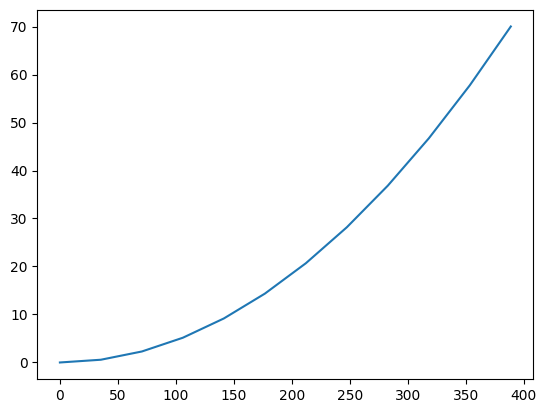

In [38]:
plt.plot(x0, z0)
plt.show()

In [39]:
q0=np.zeros(12*N)

In [40]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [41]:
h = delta_x

In [42]:
# def fun1(x_int,φ,θ,ψ):
#     A=mp*1/2*(1+x_int)*1/2*(1-x_int)*np.identity(3)
#     B=np.zeros((3,3))
#     D=1/2*(1+x_int)*1/2*(1-x_int)*I_e_rho(φ,θ,ψ)@Πe(φ,θ,ψ)
#     return h/2*np.block([[A, B], [B, D]])

# def fun2(x_int,x,y,z,φ,θ,ψ):
#     A=1/h*np.identity(3)
#     B=np.zeros((3,3))
#     C=-1/2*(1+x_int)*S(*d_s_phi(x,y,z,φ,θ,ψ))
#     return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x, y, z, φ, θ, ψ)),
#                                                           np.asarray(me( φ, θ, ψ))), axis=None)


# def fun3(x_int,φ,θ,ψ, dφ, dθ, dψ):
#     A=np.zeros(3)
#     B=1/2*(1+x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
#     return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


# def fun4(x_int,φ,θ,ψ, dφ, dθ, dψ):
#     A=np.zeros(3)   
#     B=1/2*(1+x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
#     return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


# def fun5(x_int):
#     B=np.zeros(3)   
#     A=1/2*(1+x_int)*fe_g
#     return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


# def fun6(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
#     A=1/2*(1+x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
#     B=1/2*(1+x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])

#     return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

# def fun7(x_int,x,y,z):
#     A=1/2*(1+x_int)*sigma(x,y,z)
#     B=np.zeros(3) 

#     ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

#     return ans

# def fun1(x_int,φ,θ,ψ):
#     A=mp*1/2*(1+x_int)*1/2*(1-x_int)*np.identity(3)
#     B=np.zeros((3,3))
#     D=1/2*(1+x_int)*1/2*(1-x_int)*I_e_rho(φ,θ,ψ)@Πe(φ,θ,ψ)
#     return h/2*np.block([[A, B], [B, D]])


def fun1(x_int, φ, θ, ψ):
    x_arr = np.atleast_1d(x_int) 
    num_pts = len(x_arr)
    
    coeff_A = mp * 1/2 * (1 + x_arr) * 1/2 * (1 - x_arr)  
    coeff_D = 1/2 * (1 + x_arr) * 1/2 * (1 - x_arr)      
    
   
    id3 = np.identity(3)
    zeros3 = np.zeros((3, 3))
    mat_D = I_e_rho(φ, θ, ψ) @ Πe(φ, θ, ψ)
    
    A = np.multiply.outer(id3, coeff_A)
    B = np.zeros((3, 3, num_pts))
    D = np.multiply.outer(mat_D, coeff_D)
    
    block_top = np.concatenate([A, B], axis=1)     
    block_bottom = np.concatenate([B, D], axis=1)  
    total_matrix = np.concatenate([block_top, block_bottom], axis=0) 
    
    return h / 2 * total_matrix


# def fun2(x_int,x1,y1,z1,φ1,θ1,ψ1,x2,y2,z2,h):
#     A=1/h*np.identity(3)
#     B=np.zeros((3,3))
#     C=-1/2*(1+x_int)*S(*d_s_phi(x1,y1,z1,x2,y2,z2,h))
#     return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2,h)),
#                                                           np.asarray(me( φ1, θ1, ψ1))), axis=None)


def fun2(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, h):
    x_arr = np.atleast_1d(x_int)  
    num_pts = len(x_arr)
    
    id3 = np.identity(3)
    zeros3 = np.zeros((3, 3))
    mat_S = S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
    
    coeff_C = -1/2 * (1 + x_arr)  
    
    A = np.repeat(id3[:, :, np.newaxis], num_pts, axis=2)
    B = np.zeros((3, 3, num_pts))
    C = np.multiply.outer(mat_S, coeff_C)  
    
    block_top = np.concatenate([A, B], axis=1)      
    block_bottom = np.concatenate([C, A], axis=1)   
    total_matrix = np.concatenate([block_top, block_bottom], axis=0)  
    
    total_matrix = (h / 2) * total_matrix
    
    vec_ne = np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, h))
    vec_me = np.asarray(me(φ1, θ1, ψ1))
    right_vector = np.concatenate((vec_ne, vec_me), axis=None) 
    
    return np.einsum('ijk,j->ik', total_matrix, right_vector)



# def fun3(x_int,φ,θ,ψ, dφ, dθ, dψ ):
#     A=np.zeros(3)
#     B=1/2*(1+x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
#     return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun3(x_int, φ, θ, ψ, dφ, dθ, dψ):
  
    x_arr = np.atleast_1d(x_int)  
    num_pts = len(x_arr)
    
    A = np.zeros((3, num_pts))
    

    mat_prod = I_e_rho(φ, θ, ψ) @ dΠ(φ, θ, ψ, dφ, dθ, dψ) 
    vec_diff = np.array([dφ, dθ, dψ])                     
    static_B = mat_prod @ vec_diff                        
    
    coeff_B = 1/2 * (1 + x_arr)  
    
    B = np.multiply.outer(static_B, coeff_B)  
    
    total_matrix = np.concatenate((A, B), axis=0)  
    
    return (h / 2) * total_matrix



# def fun4(x_int,φ,θ,ψ, dφ, dθ, dψ):
#     A=np.zeros(3)   
#     B=1/2*(1+x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
#     return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun4(x_int, φ, θ, ψ, dφ, dθ, dψ):
    A = np.zeros(3)
    ang_vel = Πe(φ, θ, ψ) @ np.array([dφ, dθ, dψ])
    B_base = S(*ang_vel) @ (I_e_rho(φ, θ, ψ) @ ang_vel)
    
    x_arr = np.atleast_1d(x_int)[:, np.newaxis] 
    B_scaled = 1/2 * (1 + x_arr) * B_base 
    A_repeated = np.tile(A, (len(B_scaled), 1)) 
    
    
    result = h / 2 * np.hstack((A_repeated, B_scaled)) 
    
    return result if np.isscalar(x_int) else result.T



def fun5(x_int):
    B=np.zeros(3)   
    A=1/2*(1+x_int)*fe_g
    return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


# def fun6(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
#     A=1/2*(1+x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
#     B=1/2*(1+x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])

#     return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun6(x_int, φ, θ, ψ, dx, dy, dz, dφ, dθ, dψ):
    A_base = Ret_e_t(φ, θ, ψ) @ f_t_d(dx, dy, dz)
    B_base = DR @ Πe(φ, θ, ψ) @ np.array([dφ, dθ, dψ])
    
    x_arr = np.atleast_1d(x_int)[:, np.newaxis] 
    
    A_scaled = 1/2 * (1 + x_arr) * A_base 
    B_scaled = 1/2 * (1 + x_arr) * B_base 
    
    result = h / 2 * np.hstack((A_scaled, B_scaled)) 
    
    return result[0] if np.isscalar(x_int) else result.T



# def fun7(x_int,x,y,z):
#     A=1/2*(1+x_int)*sigma(x,y,z)
#     B=np.zeros(3) 

#     ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

#     return ans

def fun7(x_int, x, y, z):
    A_base = sigma(x, y, z) 
    B_base = np.zeros(3)   
    
    x_arr = np.atleast_1d(x_int)[:, np.newaxis] 
    
    A_scaled = 1/2 * (1 + x_arr) * A_base          
    B_scaled = np.tile(B_base, (len(A_scaled), 1)) 
    
    result = h / 2 * np.hstack((A_scaled, B_scaled))
    
    return result if np.isscalar(x_int) else result.T


In [43]:
def static_solution(Q): 
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    f1=[] 
    f2=[]
    f3=[]
    f4=[]
    f5=[]
    f6=[]
#     f7=[] 

    for j in range(N):
        
#         f1.append(fun1(-1/np.sqrt(3),φ[j],θ[j],ψ[j])+fun1(1/np.sqrt(3),φ[j],θ[j],ψ[j]))
        f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int,φ[j],θ[j],ψ[j]),-1.0,1.0,n=2)[0])
        if j==0:
            f2.append(np.zeros(6))
            f3.append(np.zeros(6))
            f4.append(np.zeros(6))
            f5.append(np.zeros(6))
            f6.append(np.zeros(6))
#             f7.append(np.zeros(6))
        else:
            if j<N-1:
                f2.append(integrate.fixed_quad(lambda x_int:fun2(x_int, x[j],y[j],z[j],φ[j],θ[j],ψ[j],x[j+1],y[j+1],z[j+1],h),-1.0,1.0,n=1)[0])
            else: 
                f2.append(integrate.fixed_quad(lambda x_int:fun2(x_int, x[j],y[j],z[j],φ[j],θ[j],ψ[j],x[j]+1,y[j]+1,z[j]+1,h),-1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int:fun3(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]),-1.0,1.0,n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int:fun4(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]),-1.0,1.0,n=2)[0])
            f5.append(fun5(-1/np.sqrt(3))+fun5(1/np.sqrt(3)))
            f6.append(integrate.fixed_quad(lambda x_int: fun6(x_int,φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j]),-1.0,1.0,n=2)[0])
#             f7.append(integrate.fixed_quad(lambda x_int: fun7(x_int,x[j-1],y[j-1],z[j-1]),-1.0,1.0,n=2)[0])
            #             f2.append(2*fun2(0,x[j],y[j],z[j],φ[j],θ[j],ψ[j]))
#             f2.append(fun2(-1/np.sqrt(3),x[j],y[j],z[j],φ[j],θ[j],ψ[j])
#                       +fun2(1/np.sqrt(3),x[j],y[j],z[j],φ[j],θ[j],ψ[j]))
#             f3.append(fun3(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]) 
#                       +fun3(1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
#             f4.append(fun4(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
#                                 +fun4(1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
#             f5.append(fun5(-1/np.sqrt(3))+fun5(1/np.sqrt(3)))
#             f6.append(fun6(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j])
#                                 +fun6(1/np.sqrt(3),φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j]))
    #         f7.append(fun7(-1/np.sqrt(3),x[j],y[j],z[j])+fun7(1/np.sqrt(3),x[j],y[j],z[j]))

    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
    f7=np.vstack(f6) 
    

    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
    for i in range(N):
        ddx[i],ddy[i],ddz[i], ddφ[i],ddθ[i],ddψ[i] =  scipy.sparse.linalg.spsolve(scipy.sparse.csr_matrix(f1[i]), 
                                                           (f2[i]+f3[i]+f4[i]
                                                            +f5[i]
                                                            +f6[i]
#                                                     +f7[i]
                                                   ).reshape(6,1))
  

    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    
    return ans

In [44]:
root_ = root(static_solution, q0
#              , method='lm'
            )

In [45]:
root_

 message: The iteration is not making good progress, as measured by the 
            improvement from the last ten iterations.
 success: False
  status: 5
     fun: [ 0.000e+00  0.000e+00 ...  0.000e+00  4.241e+05]
       x: [ 0.000e+00  3.537e+01 ...  0.000e+00  0.000e+00]
  method: hybr
    nfev: 299
    fjac: [[ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00 -2.287e-19 ...  3.005e-19 -1.345e-10]
           ...
           [ 0.000e+00 -1.967e-41 ...  4.981e-20 -1.466e-09]
           [ 0.000e+00  9.720e-41 ... -2.770e-19  1.119e-08]]
       r: [-0.000e+00  0.000e+00 ... -1.103e-10  1.000e+00]
     qtf: [ 0.000e+00  2.862e+08 ... -2.861e+02 -5.757e+03]

In [46]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [47]:
q0 = root_.x                                         # start from static solution

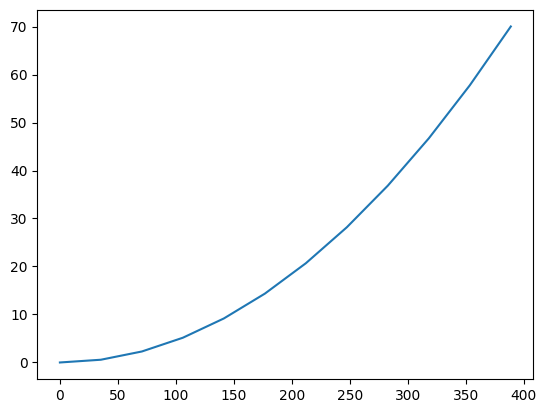

In [48]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [49]:
sampleTime = 0.01              # sample time [seconds]
Number = 6000                      # number of samples

In [50]:
Number*sampleTime

60.0

In [51]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [52]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [53]:
simData.shape 

(6001, 24)

In [54]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

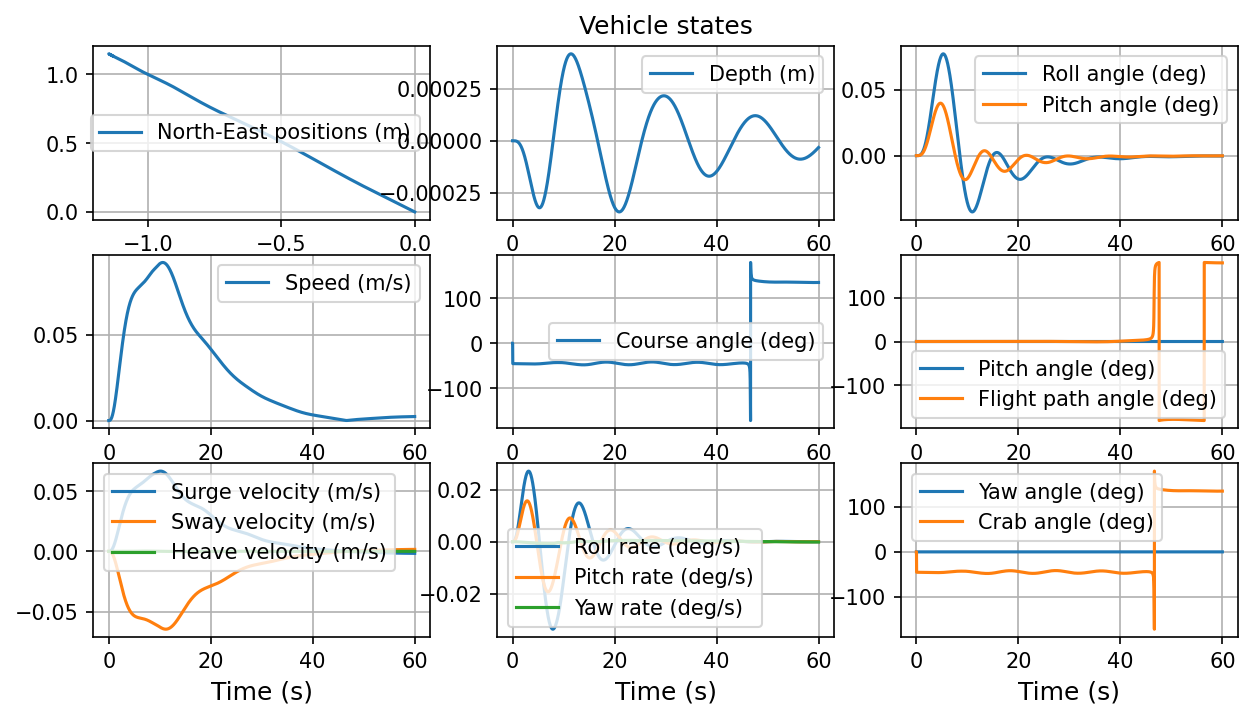

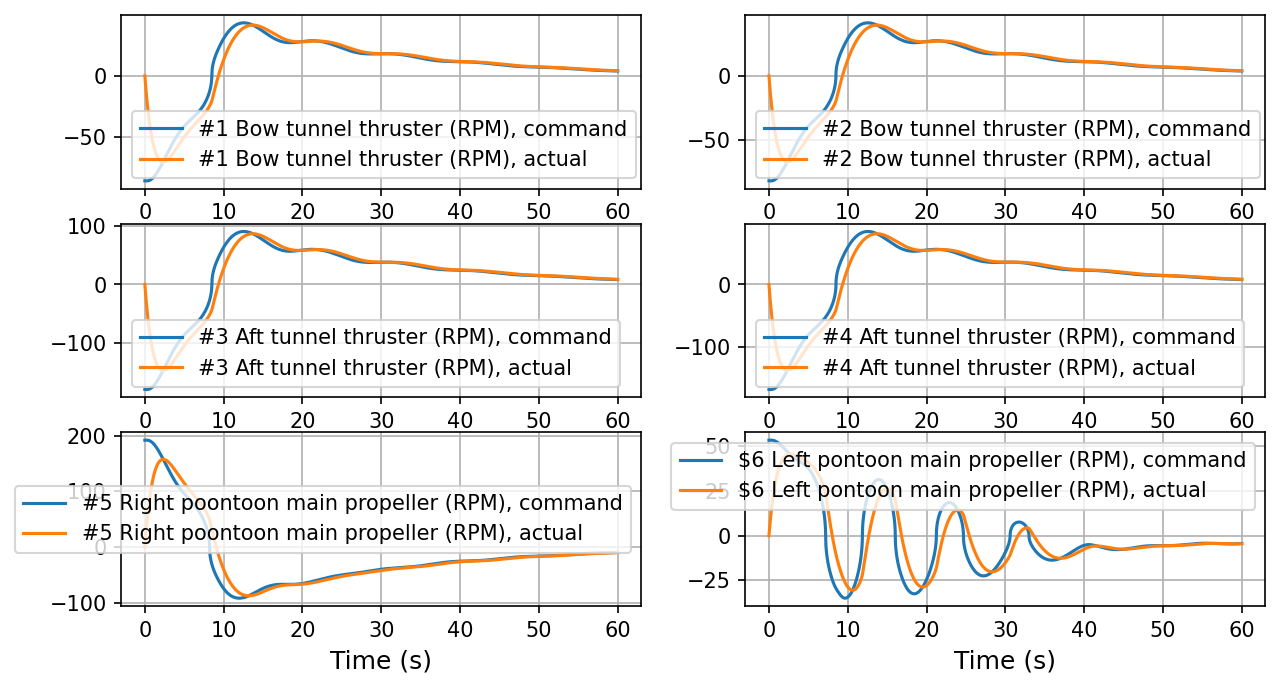

In [55]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [56]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

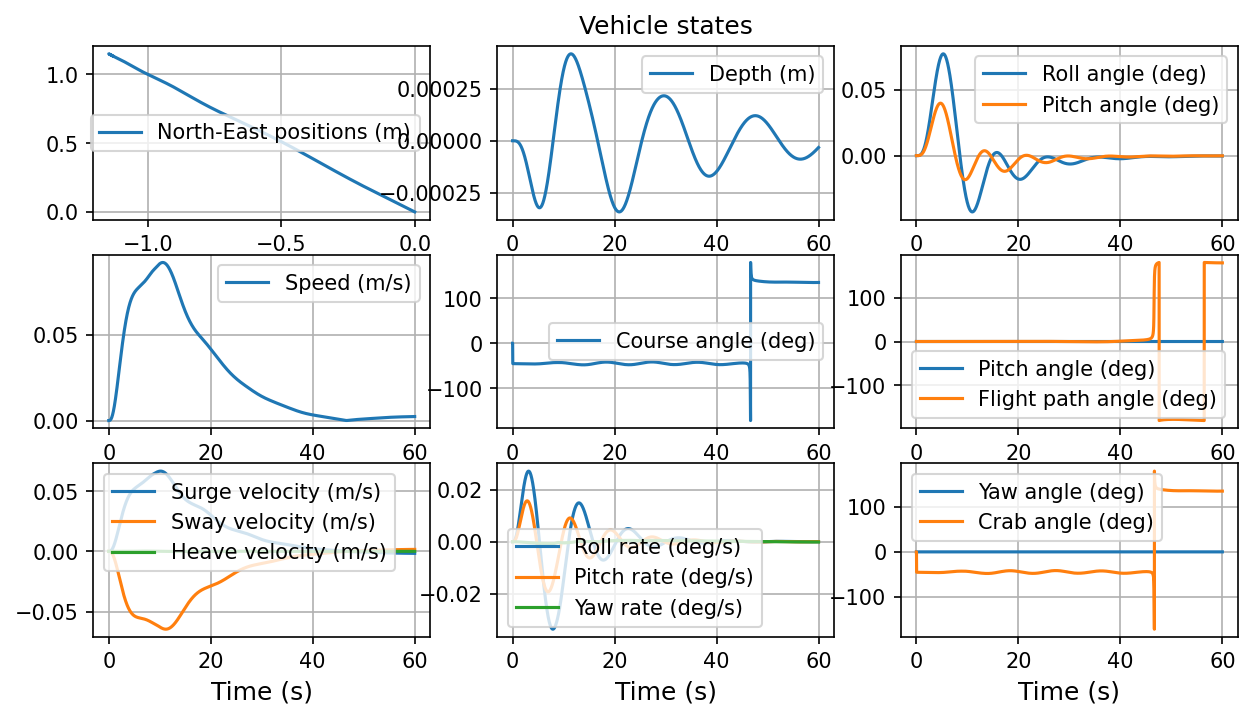

In [57]:
plotVehicleStates(simTime, simData, 3)

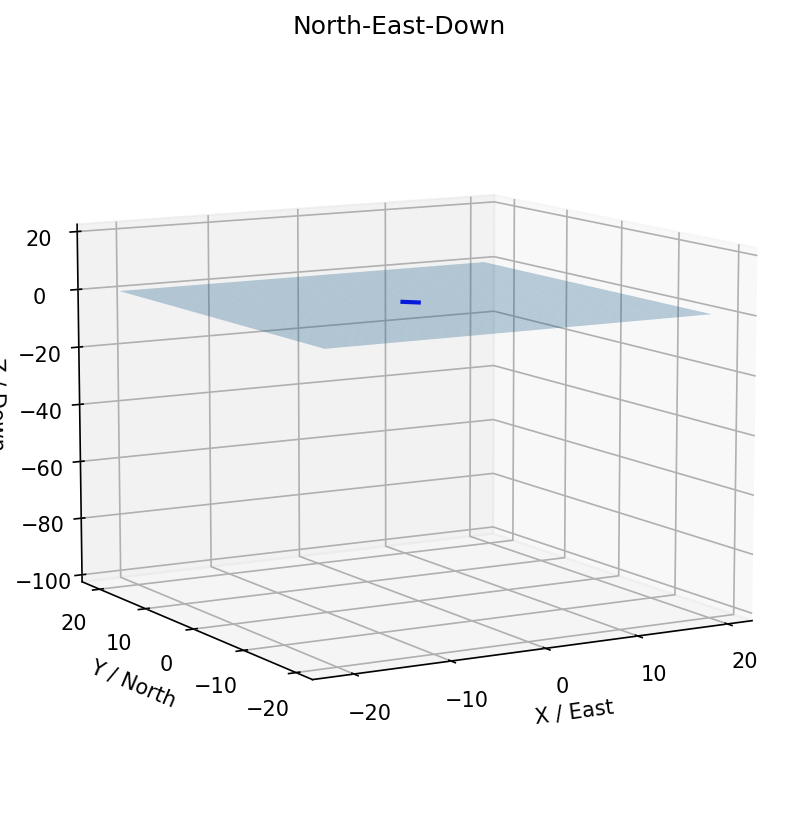

In [58]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [59]:
simData.shape

(6001, 24)

In [60]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [61]:
class MyTime:
    def __init__(self):
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0
        self.force_factor=1e3

In [62]:
vessel_motion_func = interp1d(
    ans_t, simData[:, 18:24], axis=0, kind="linear", fill_value="extrapolate"
)

### Dynamic Simulation

In [67]:
def dynamic_func(t, Q, T):
    
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
      
    u_actual = T.force_factor*vessel_motion_func(t)
    
    u_actual_x = u_actual[0]
    u_actual_y = u_actual[1]
    u_actual_z = u_actual[2]
    u_actual_phi = u_actual[3]
    u_actual_theta = u_actual[4]
    u_actual_psi = u_actual[5]
    
         
    f1=[] 
    f2=[]
    f3=[]
    f4=[]
    f5=[]
    f6=[]
    f7=[]
    f8=[]
    
#     for j in range(N):
        
#         f1.append(fun1(-1/np.sqrt(3),φ[j],θ[j],ψ[j])+fun1(1/np.sqrt(3),φ[j],θ[j],ψ[j]))
        
#         if j==0:
#             f2.append(np.zeros(6))
#             f3.append(np.zeros(6))
#             f4.append(np.zeros(6))
#             f5.append(np.zeros(6))
#             f6.append(np.zeros(6))
# #             f7.append(np.zeros(6))
#             f8.append(np.zeros(6))
#         else:
#             f2.append(2*fun2(0,x[j],y[j],z[j],φ[j],θ[j],ψ[j]))
#             f3.append(fun3(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
#                       +fun3(1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
#             f4.append(fun4(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
#                       +fun4(1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
#             f5.append(fun5(-1/np.sqrt(3))+fun5(1/np.sqrt(3)))
#             f6.append(fun6(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j])
#                       +fun6(1/np.sqrt(3),φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j]))
#             f7.append(fun7(-1/np.sqrt(3),x[j],y[j],z[j])+fun7(1/np.sqrt(3),x[j],y[j],z[j]))

    for j in range(N):
        
#         f1.append(fun1(-1/np.sqrt(3),φ[j],θ[j],ψ[j])+fun1(1/np.sqrt(3),φ[j],θ[j],ψ[j]))
        f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int,φ[j],θ[j],ψ[j]),-1.0,1.0,n=2)[0])
        if j==0:
            f2.append(np.zeros(6))
            f3.append(np.zeros(6))
            f4.append(np.zeros(6))
            f5.append(np.zeros(6))
            f6.append(np.zeros(6))
#             f7.append(np.zeros(6))
            f8.append(np.zeros(6))
        else:
            if j<N-1:
                f2.append(integrate.fixed_quad(lambda x_int:fun2(x_int, x[j],y[j],z[j],φ[j],θ[j],ψ[j],x[j+1],y[j+1],z[j+1],h),-1.0,1.0,n=1)[0])
            else: 
                f2.append(integrate.fixed_quad(lambda x_int:fun2(x_int, x[j],y[j],z[j],φ[j],θ[j],ψ[j],x[j]+0.1,y[j]+0.1,z[j]+0.1,h),-1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int:fun3(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]),-1.0,1.0,n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int:fun4(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]),-1.0,1.0,n=2)[0])
            f5.append(fun5(-1/np.sqrt(3))+fun5(1/np.sqrt(3)))
            f6.append(integrate.fixed_quad(lambda x_int: fun6(x_int,φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j]),-1.0,1.0,n=2)[0])
            f8.append(int(j==(N-1))*np.block([[np.identity(3), np.zeros((3,3))], 
                                [np.zeros((3,3)), np.identity(3)]])@u_actual)
    
    
       
        if t>0.001:
            if j<N-1:
                ax=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j]))@ ne(x[j], y[j], z[j], φ[j], θ[j], ψ[j],x[j+1],y[j+1],z[j+1],h).T
                T.top_tension=max(T.top_tension, ax[0][0])            

            ben0=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j])) @ me( φ[j], θ[j], ψ[j]).T
            ben=np.max(ben0[1:])

            I=3.14*(d0**4-dI**4)/64
            strain=np.max(ben)*d0/(2*E*I)    

            T.sagbend_strain=max(T.sagbend_strain, strain)
            
    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
#     f7=np.vstack(f7)
    f8=np.vstack(f8) 

    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
    for i in range(N):
        ddx[i],ddy[i],ddz[i], ddφ[i],ddθ[i],ddψ[i] = scipy.sparse.linalg.spsolve(scipy.sparse.csr_matrix(f1[i]),
                                                                                 (
#                                                                                      f2[i]
                                                                                     +f3[i]+f4[i]+f5[i]+f6[i]
#                                                                                  +f7[i]
                                                                                   +f8[i]
                                                   ).reshape(6,1))      
        
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    

    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()  
        
        
    T.my_iter+=1 
    
    
    return ans

In [68]:
T_ = MyTime()

In [69]:
# initial conditions - to control dynamics

# BC=np.zeros(N)
# BC[-1]=0.013
# q0[8*N:9*N] = BC

q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.00003 for i in range(N)]),
                                          np.array([0.001767*i/N for i in range(N)]))

In [70]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(T_, ), 
#              method='RK23'
             method='BDF',
               )
print(datetime.now() - startTime1)

Physical time:  5.994284902160364e-07  Iteration wall-clock time:  0:00:00.790911
0:01:12.092034


In [71]:
#15:07

### Results

In [72]:
T_.my_iter

8409

In [73]:
# max axial tension
T_.top_tension

0

In [74]:
# max bending strain
T_.sagbend_strain

7.5605673431006934

In [75]:
fin=us_

In [76]:
fin

  message: Required step size is less than spacing between numbers.
  success: False
   status: -1
        t: [ 0.000e+00  1.111e-05 ...  6.090e-02  6.090e-02]
        y: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 3.537e+01  3.537e+01 ...  3.537e+01  3.537e+01]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  4.888e-09 ...  9.459e-02  9.459e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 579
     njev: 54
      nlu: 102

In [77]:
t=fin.t

In [78]:
fin=fin.y.T

In [79]:
t.shape, fin.shape

((139,), (139, 144))

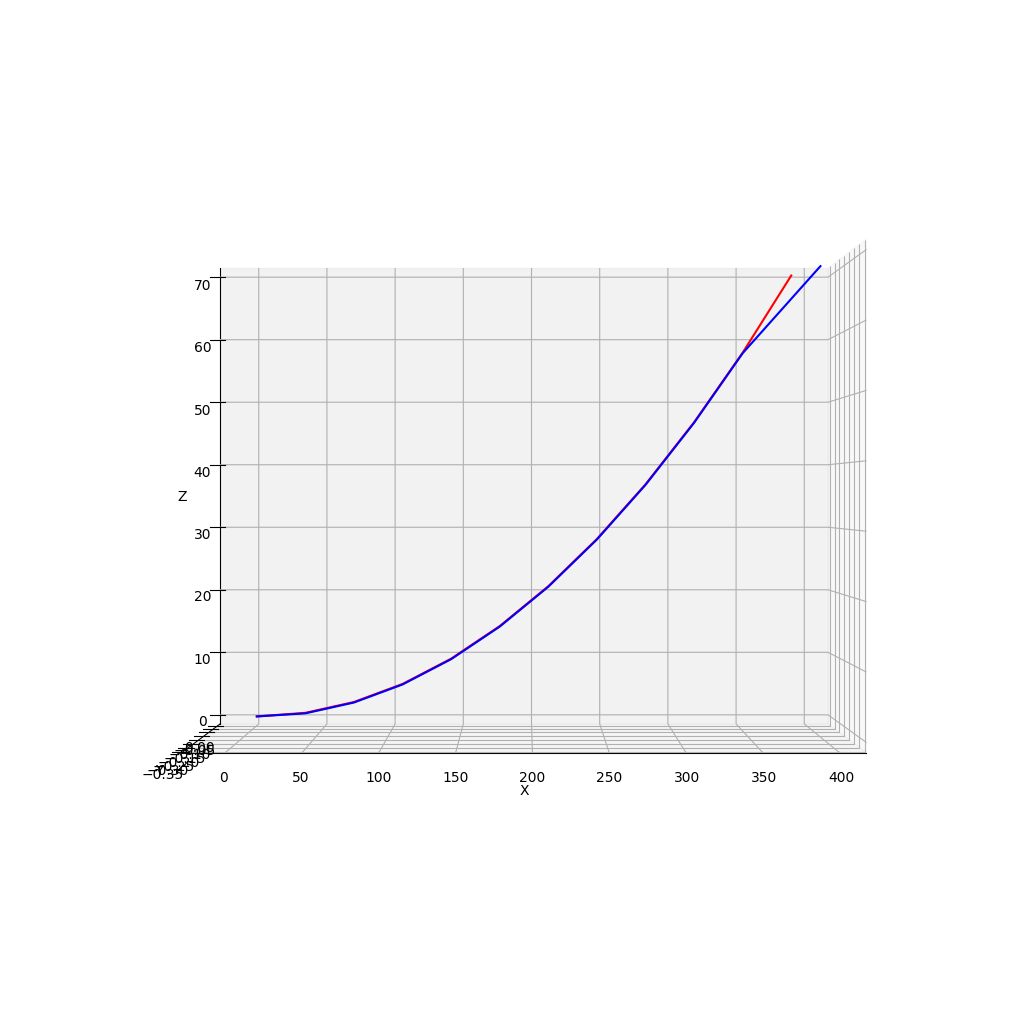

In [80]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [81]:
X,Y,Z

(array([  0.        ,  35.36609963,  70.73220013, 106.09830062,
        141.46440112, 176.83050162, 212.19660212, 247.56270262,
        282.92880311, 318.29490361, 353.66100411, 388.99021425]),
 array([ 0.        ,  0.00040484,  0.00040484,  0.00040484,  0.00040484,
         0.00040484,  0.00040484,  0.00040484,  0.00040484,  0.00040484,
         0.00040484, -0.33989696]),
 array([ 0.        ,  0.48897086,  2.20724308,  5.07303145,  9.08934017,
        14.26037954, 20.59157036, 28.08954963, 36.76217748, 46.61854541,
        57.66898587, 67.89719881]))

In [82]:
X0,Y0,Z0

(array([  0.        ,  35.36610051,  70.73220103, 106.09830154,
        141.46440206, 176.83050257, 212.19660309, 247.5627036 ,
        282.92880412, 318.29490463, 353.66100515, 389.02710566]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([ 0.        ,  0.57255734,  2.29082955,  5.15661792,  9.17292664,
        14.34396601, 20.67515684, 28.17313611, 36.84576395, 46.70213189,
        57.75257235, 70.00866951]))

In [83]:
us=fin.T

In [84]:
us.shape

(144, 139)

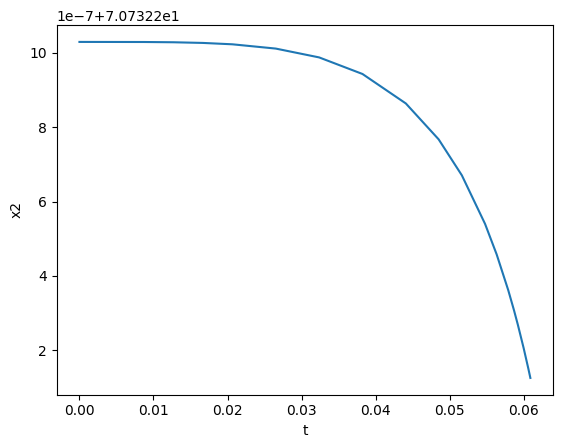

In [85]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

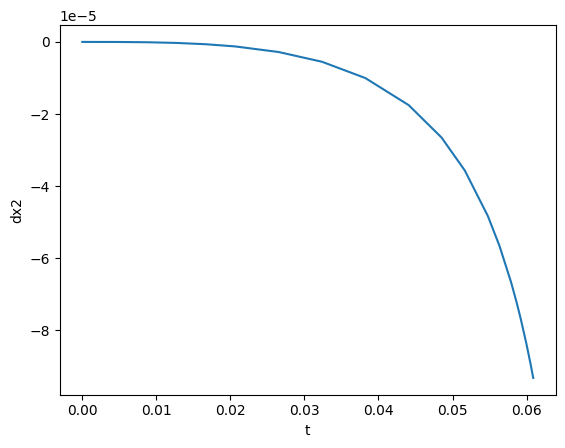

In [86]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

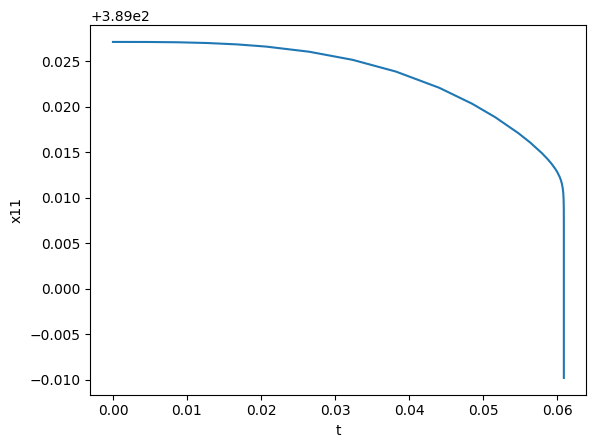

In [87]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

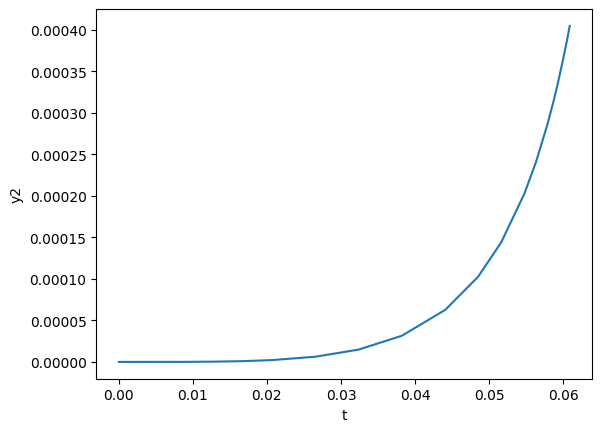

In [88]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

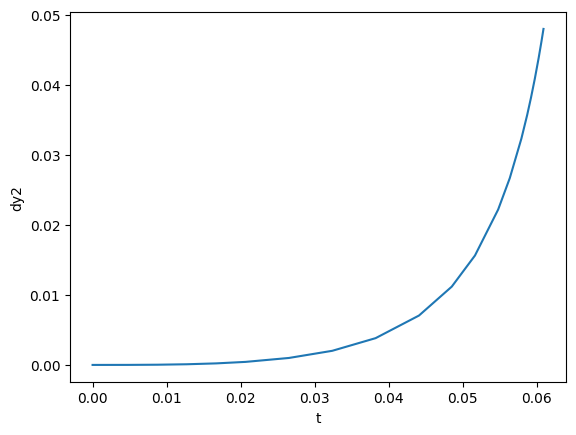

In [89]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

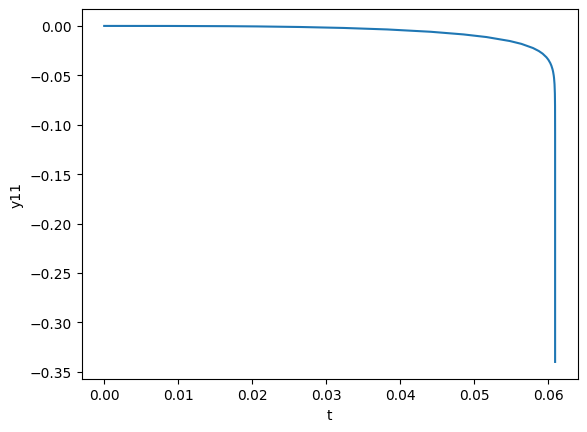

In [90]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

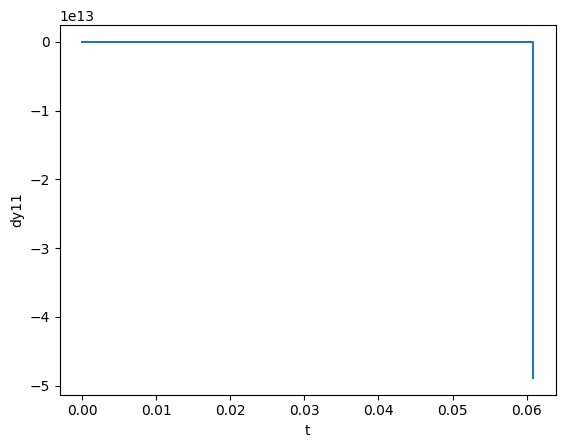

In [91]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

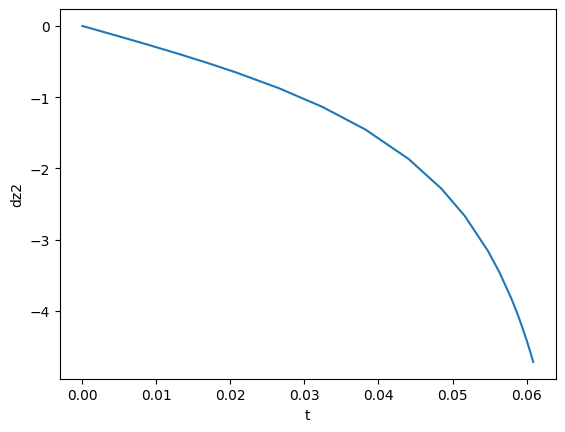

In [92]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

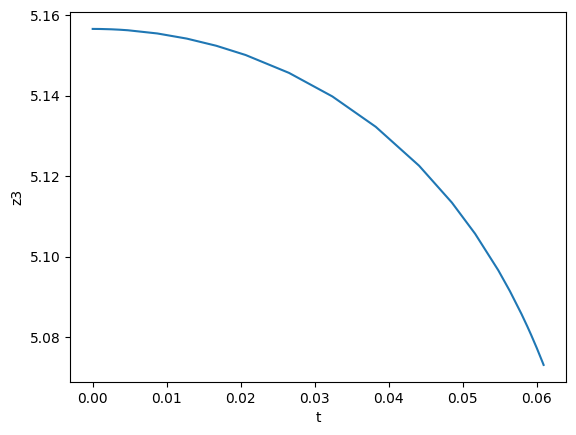

In [93]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

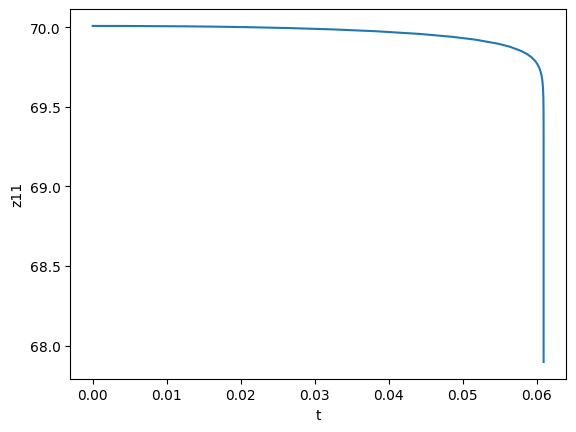

In [94]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

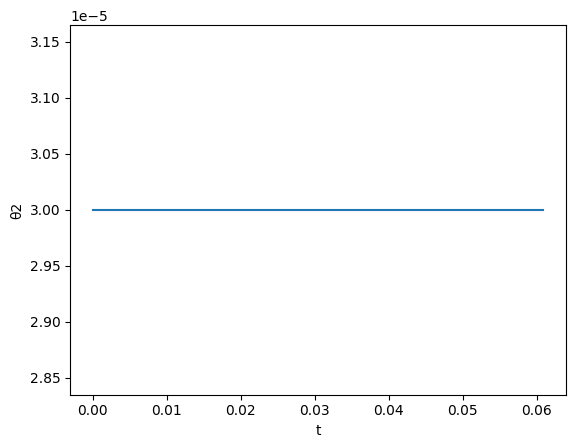

In [95]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

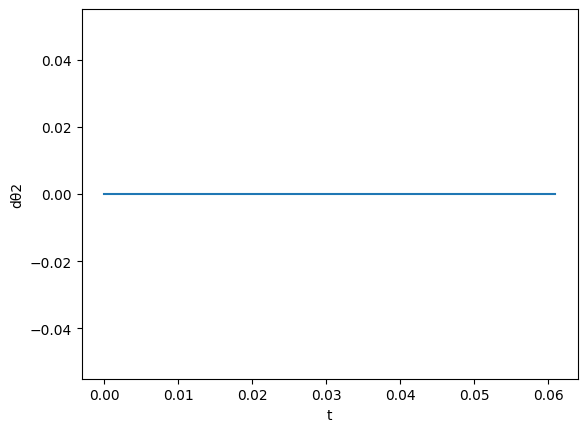

In [96]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

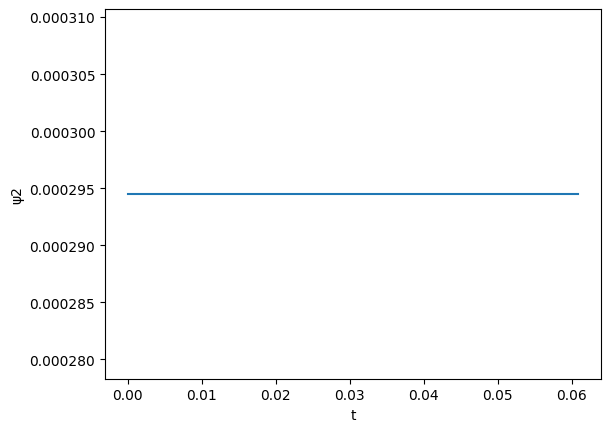

In [97]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

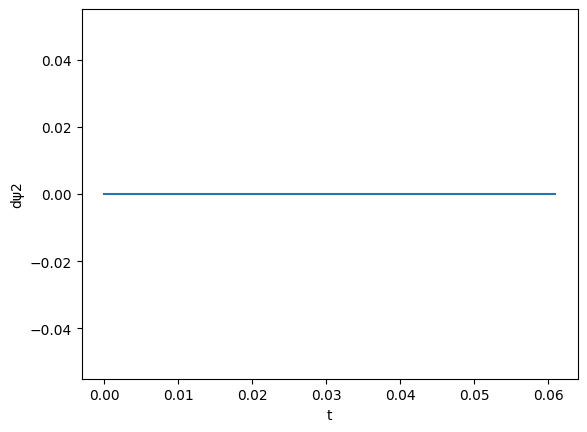

In [98]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

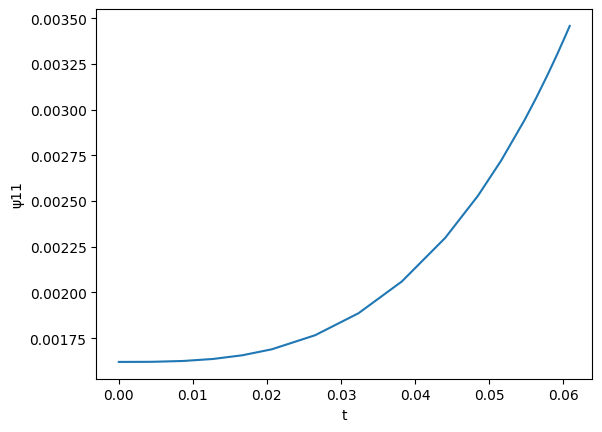

In [99]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [100]:
X010=us.T[:,0*N:1*N]

In [101]:
Y010=us.T[:,2*N:3*N]

In [102]:
Z010=us.T[:,4*N:5*N]

In [ ]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()